# Hourglass Image Analysis Pipeline

This notebook aims to demostrate how to use QIM3D to segment and count the particles of [Hourglass](https://data.qim.dk/pages/hourglass.html)

### 0. Imports

In [1]:
import qim3d
from tifffile import TiffFile
from pprint import pprint
import dask.array as da
import numpy as np

## 1. Downloading and Inspecting Available Datasets

The first step is to obtain the data. The `qim3d.io.Downloader` provides an interface for listing, downloading, and loading the demonstration files included with QIM3D.
A Downloader object is created to establish the connection to the remote archive (or local cache) where the example datasets are stored.

In [2]:
downloader = qim3d.io.Downloader()

Calling `downloader.list_files()` prints out the names of all datasets you can fetch. This gives a quick overview of what’s ready to download.

In [3]:
downloader.list_files()


╭──────╮
│ Coal │
╰──────╯
Coal.CoalBrikett                                  (2.24GB)
Coal.CoalBrikettZoom_DOWNSAMPLED                  (238.50MB)
Coal.CoalBrikett_Zoom                             (3.73GB)

╭────────╮
│ Corals │
╰────────╯
Corals.Coral_1                                    (2.27GB)
Corals.Coral_2                                    (2.38GB)
Corals.Coral2_DOWNSAMPLED                         (152.66MB)
Corals.Coral_1_1                                  (1.83GB)
Corals.Coral_1_2                                  (1.83GB)
Corals.Coral_1_3                                  (1.83GB)
Corals.MexCoral                                   (2.24GB)

╭─────────────╮
│ Cowry_Shell │
╰─────────────╯
Cowry_Shell.Cowry_DOWNSAMPLED                     (116.91MB)
Cowry_Shell.Cowry_Shell                           (1.83GB)

╭──────╮
│ Crab │
╰──────╯
Crab.HerrmitCrab                                  (2.38GB)
Crab.OkinawaCrab                                  (1.86GB)

╭───────────────╮
│ Deer_Man

Once the desired file name is identified, it can be loaded with a single command. In this example, the Hourglass dataset is selected, and setting `load_file=True` ensures it is downloaded and instantiated immediately.

In [4]:
vol = downloader.Hourglass.Hourglass_4X_80kV_Air_9s_1_97um(load_file=True)

File already downloaded:
/home/s215170/Repos/qim3d/docs/notebooks/Hourglass/Hourglass_4X-80kV-Air-9s-1_97um.tif

Loading Hourglass_4X-80kV-Air-9s-1_97um.tif
Using virtual stack


The volume is downsampled to ensure the example can be run easily on any laptop.

In [5]:
vol_downsampled = vol[::2, ::2, ::2]

## 2. Exploring Data Properties & Basic Visualization


To start the data exploration, some basic information is printed. The volume is 3D, single-channel, and uses 16-bit unsigned integers for pixel values.

In [6]:
print("Original shape:", vol.shape)
print("Downsampled Shape:", vol_downsampled.shape) 
print("Dtype:", vol_downsampled.dtype)
print("Channels:", 1 if vol_downsampled.ndim == 3 else vol_downsampled.shape[-1])
vmin = np.min(vol_downsampled)
vmax = np.max(vol_downsampled)

print("Minimum value:", vmin)
print("Maximum value:", vmax)

Original shape: (994, 1014, 976)
Downsampled Shape: (497, 507, 488)
Dtype: >u2
Channels: 1
Minimum value: 0
Maximum value: 58121


The next step in data exploration is visualization. QIM3D provides several visualization methods, but for an initial inspection the orthogonal slicer is particularly useful.

In [7]:
qim3d.viz.slicer_orthogonal(vol_downsampled, colormap="grey")

This tool shows three perpendicular cross-sections: Axial (Z), Coronal (Y), and Sagittal (X), with interactive sliders that allow real-time navigation through the volume. It offers a fast and intuitive way to examine the 3D structure from all major orthogonal planes.

Since the final goal is segmentation, the data’s histogram can then be explored to identify a suitable threshold. QIM3D provides an interactive tool that make it possible to test different thresholding methods and values while immediately previewing their effects, simplifying the process of selecting the most appropriate threshold for the dataset.

In [8]:
qim3d.viz.threshold(vol_downsampled)

## 3. Segmentation and Particle Counting

The process begins with the application of a Gaussian filter to smooth the data and reduce noise. The filtered volume is then thresholded at 17,000 to generate a binary mask, where voxels above the threshold are assigned True. The resulting segmentation is visualized across slices along axis 1 using `qim3d.viz.slices_grid`.

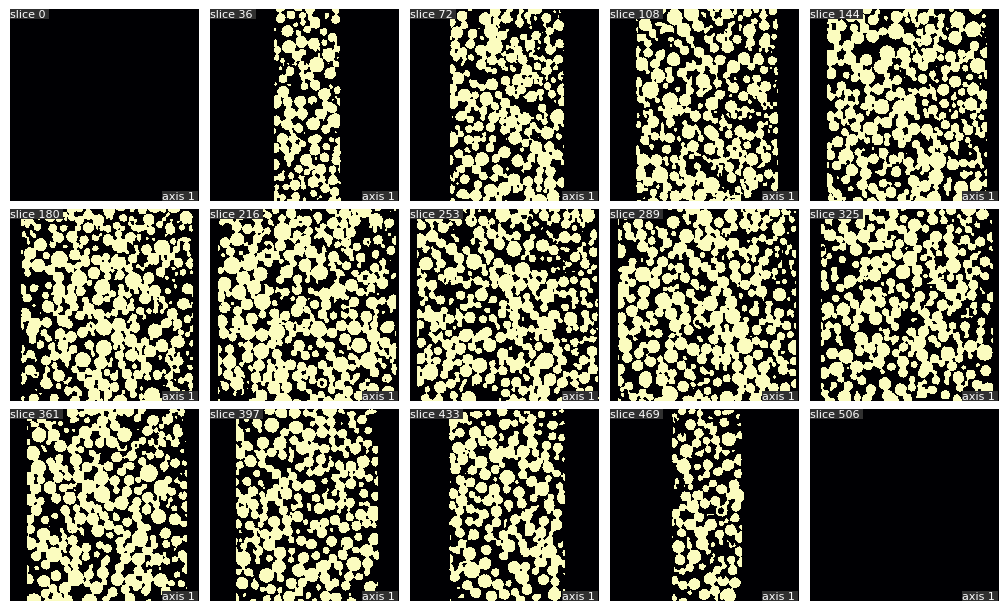

In [9]:
bin_vol = qim3d.filters.gaussian(vol_downsampled, sigma = 2)>17000

fig1 = qim3d.viz.slices_grid(bin_vol, slice_axis=1, display_figure=True)

A 3D morphological opening is then applied using a (6,6,6) kernel. Morphological opening, consisting of erosion followed by dilation, removes small noisy specks and smooths particle boundaries, resulting in a cleaner segmentation prior to labeling.

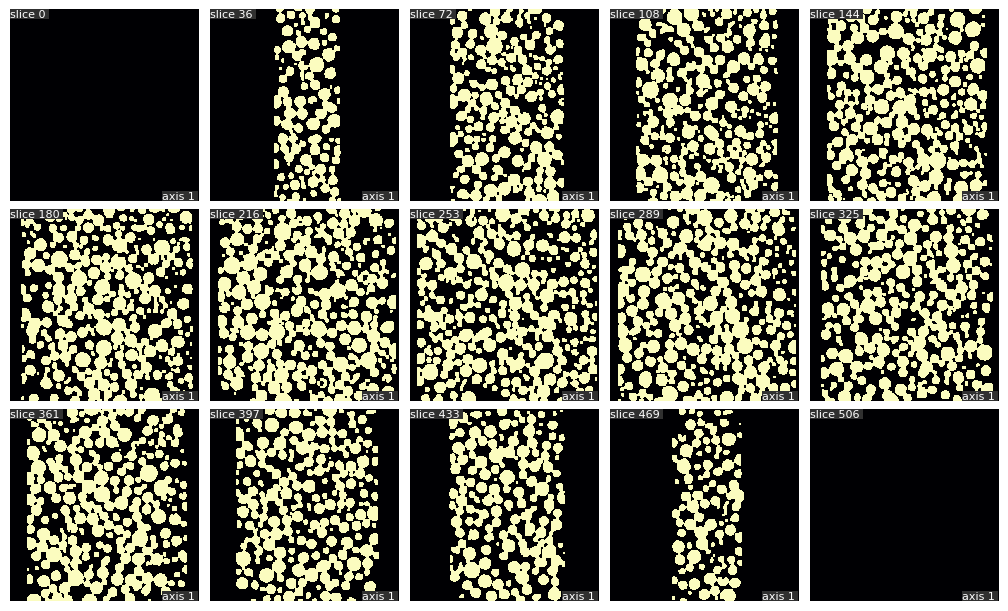

In [10]:
bin_vol_opened = qim3d.morphology.opening(bin_vol, kernel=(6,6,6), method='scipy.ndimage')

fig2 = qim3d.viz.slices_grid(bin_vol_opened, slice_axis=1, display_figure=True)

3D watershed segmentation is applied to the binary mask to separate touching or overlapping particles. The algorithm uses the distance transform to identify local maxima within each object, and the parameter `min_distance=5` specifies that two peaks must be at least 5 voxels apart to be considered distinct. The process produces a labeled volume in which each particle is assigned a unique integer label, along with the total number of segmented particles in the dataset.

In [11]:
labeled_volume, num_labels = qim3d.segmentation.watershed(bin_vol_opened, min_distance=5)

Total number of objects found: 4749


After labeling the particles using watershed segmentation, the segmented volume is visualized. A color map is generated with as many distinct colors as there are detected particles, and each label in the volume is assigned a unique color to facilitate differentiation. A grid of slices through the labeled volume is then displayed along the selected axis to allow qualitative inspection of the segmentation.

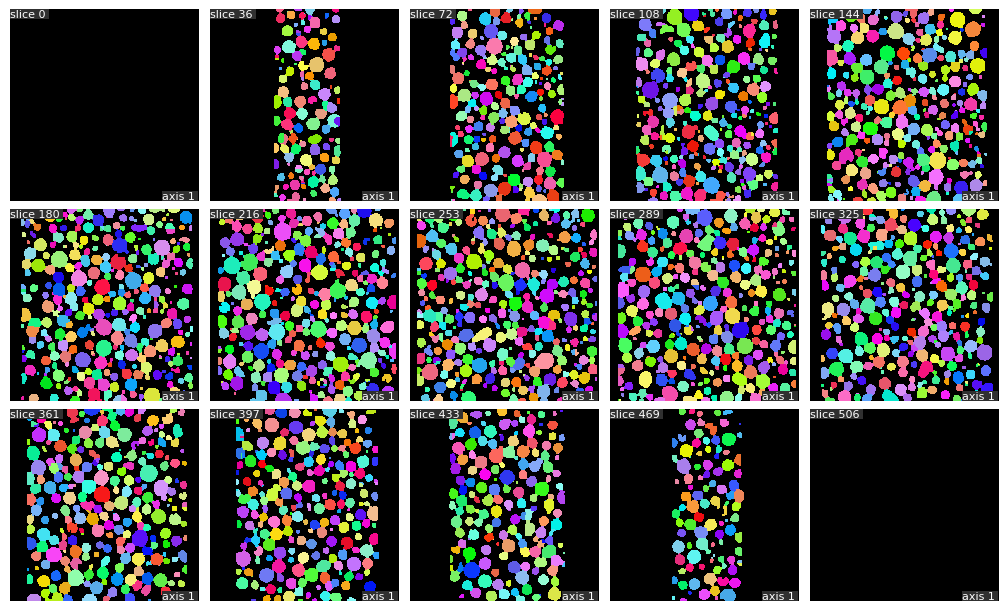

In [12]:
cmap = qim3d.viz.colormaps.segmentation(num_labels)
fig2 = qim3d.viz.slices_grid(labeled_volume, slice_axis=1, colormap=cmap, display_figure=True)

In [13]:
qim3d.viz.volumetric(labeled_volume, colormap=cmap, min_value=0, max_value=num_labels, opacity_function='constant')

Downsampled image for visualization, from (497, 507, 488) to (256, 261, 251)


Output()